In [1]:
import sys
print("Python Path:", sys.executable)
print("Virtual Environment Active:", 'titanic_env' in sys.executable)

# Test all imports
try:
    import pandas as pd
    print(f"✅ Pandas {pd.__version__}")
    
    import numpy as np
    print(f"✅ NumPy {np.__version__}")
    
    import matplotlib.pyplot as plt
    print("✅ Matplotlib imported")
    
    import seaborn as sns
    print("✅ Seaborn imported")
    
    from sklearn.model_selection import train_test_split
    print("✅ Scikit-learn imported")
    
    print("\n🎉 All packages installed successfully!")
    
except ImportError as e:
    print(f"❌ Import failed: {e}")

Python Path: c:\Users\farah\Downloads\Titanic project\titanic_env\Scripts\python.exe
Virtual Environment Active: True
✅ Pandas 2.3.0
✅ NumPy 2.3.1
✅ Matplotlib imported
✅ Seaborn imported
✅ Scikit-learn imported

🎉 All packages installed successfully!


In [2]:
# %% Data Preprocessing
print("\n3. DATA PREPROCESSING...")
# Add preprocessing code here...



3. DATA PREPROCESSING...


In [3]:
# %% Model Training
print("\n4. MODEL TRAINING...")
# Add model training code here...


4. MODEL TRAINING...


In [4]:
# %% Setup and Imports
import sys
print("Python Path:", sys.executable)
print("Virtual Environment Active:", 'titanic_env' in sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All imports successful!")
print("Setup complete! 🎉")

Python Path: c:\Users\farah\Downloads\Titanic project\titanic_env\Scripts\python.exe
Virtual Environment Active: True
All imports successful!
Setup complete! 🎉


In [10]:
# %% Change Directory and Load Data
import os
import pandas as pd

# Change to project directory
project_dir = r"C:\Users\farah\Downloads\Titanic project"
os.chdir(project_dir)

print("Changed to directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
print("Files in data directory:", os.listdir('data'))

# Now load data with relative path
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"✅ Training Data Shape: {train_df.shape}")
print(f"✅ Test Data Shape: {test_df.shape}")
print(train_df.head())

Changed to directory: C:\Users\farah\Downloads\Titanic project
Files in current directory: ['.gitignore', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src', 'submissions', 'titanic_analysis.py', 'titanic_env', 'visualizations']
Files in data directory: ['test.csv', 'train.csv']
✅ Training Data Shape: (891, 12)
✅ Test Data Shape: (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr

In [11]:
# %% Data Exploration
print("=== TITANIC DATASET ANALYSIS ===")
print(f"Total passengers in training: {len(train_df)}")
print(f"Total passengers in test: {len(test_df)}")

print(f"\nSurvival Statistics:")
print(f"Survived: {train_df['Survived'].sum()} passengers ({train_df['Survived'].mean():.1%})")
print(f"Died: {(train_df['Survived'] == 0).sum()} passengers ({(train_df['Survived'] == 0).mean():.1%})")

print(f"\nMissing Data:")
print(train_df.isnull().sum())

print(f"\nPassenger Classes:")
print(train_df['Pclass'].value_counts().sort_index())

print(f"\nGender Distribution:")
print(train_df['Sex'].value_counts())

=== TITANIC DATASET ANALYSIS ===
Total passengers in training: 891
Total passengers in test: 418

Survival Statistics:
Survived: 342 passengers (38.4%)
Died: 549 passengers (61.6%)

Missing Data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Passenger Classes:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Gender Distribution:
Sex
male      577
female    314
Name: count, dtype: int64


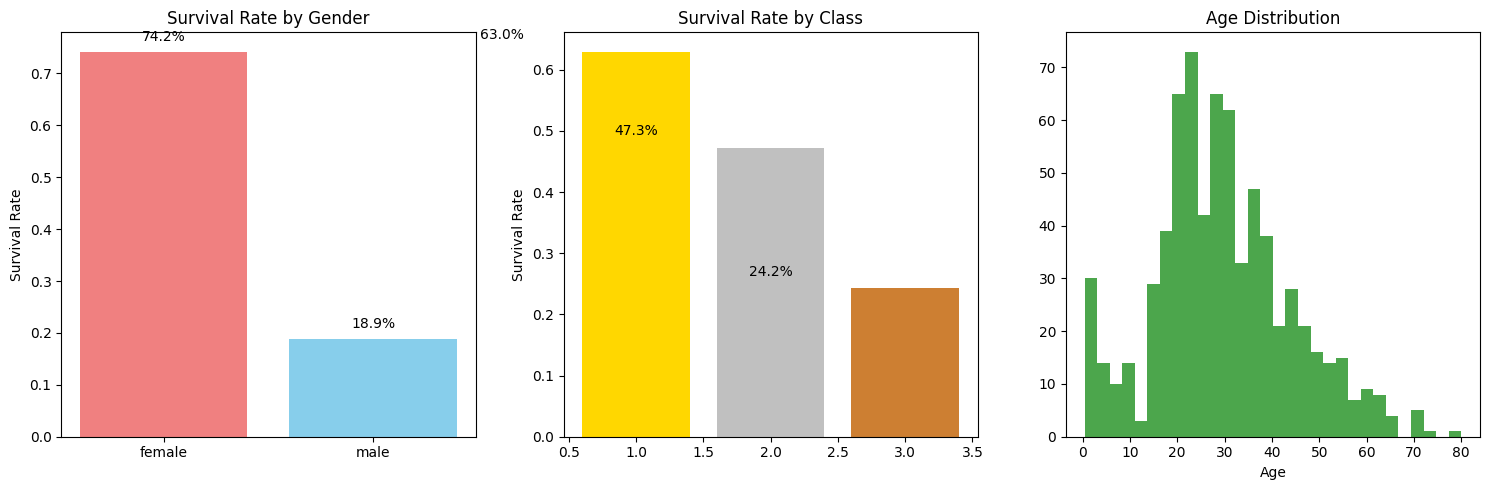

Key Insights:
- Women survived at 74.2% rate
- Men survived at 18.9% rate
- 1st class: 63.0% survival rate
- 3rd class: 24.2% survival rate


In [12]:
# %% Basic Survival Analysis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Survival by Gender
survival_gender = train_df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean'])
axes[0].bar(survival_gender.index, survival_gender['mean'], color=['lightcoral', 'skyblue'])
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_gender['mean']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Survival by Class
survival_class = train_df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean'])
axes[1].bar(survival_class.index, survival_class['mean'], color=['gold', 'silver', '#CD7F32'])
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_class['mean']):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center')

# Age distribution
axes[2].hist(train_df['Age'].dropna(), bins=30, alpha=0.7, color='green')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("Key Insights:")
print(f"- Women survived at {survival_gender.loc['female', 'mean']:.1%} rate")
print(f"- Men survived at {survival_gender.loc['male', 'mean']:.1%} rate") 
print(f"- 1st class: {survival_class.loc[1, 'mean']:.1%} survival rate")
print(f"- 3rd class: {survival_class.loc[3, 'mean']:.1%} survival rate")